In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scipy.stats as stats
from scipy.stats import mannwhitneyu
import seaborn as sns

# Upravení datasetů a výpočty parametrů

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df1 = pd.read_excel("dtab.xlsx")
df1.head()


,№№,Označení,Místo práce,Profese,Manuální lateralita,Věk,Vyška,Váha,Pohlaví,%Fmax_FR,...,%Fmax_EL,PohybyRH/směna,PohybyLH/směna,Kategoria práce,HAL-R,HAL-L,NPF-R,NPF-L,POMĚR-R,POMĚR-L
0,1,kuchař1,ChechInnHotel,kuchař,Pr,33,185,90,M,7.90,...,6.30,15000,9000,2,4.5,4.0,2.0,1.5,0.900,0.6
1,2,servírka1,ChechInnHotel,servírka,Pr,53,149,62,Ž,9.10,...,7.00,10000,5000,2,4.5,4.0,2.5,2.0,1.125,0.8
2,3,Pomoc1,ChechInnHotel,pomocná,Pr,52,167,85,Ž,12.63,...,8.94,20000,10000,3,4.5,4.0,3.5,3.0,1.575,1.2
3,4,Pomoc2,ChechInnHotel,pomocná,Pr,52,165,94,Ž,12.16,...,8.08,20000,10000,3,4.5,4.0,4.0,3.5,1.800,1.4
4,5,Pokojsk1,ChechInnHotel,pokojska,Pr,38,165,55,Ž,16.80,...,14.69,16500,10500,3,5.5,5.0,4.5,4.0,2.475,2.0


In [ ]:
import glob

file_paths = glob.glob("/content/drive/MyDrive/ergo conference/fin_5_tabl/*.xlsx")


tables = []

for file in sorted(file_paths):
    df = pd.read_excel(file)
    tables.append(df)

df = pd.concat(tables, ignore_index=True)
df.head(18)

,ParticipantID,Gender,Laterality,Height,Weight,Age,Occupation,Segmenttype,F_L_%MVC_median,F_L_%MVC_p25,...,CCI_R_p25,CCI_R_p75,CCI_L_Nízký (<19 %),CCI_L_Optimální (20–49 %),CCI_L_Vysoký (50–74 %),CCI_L_Extrémně vysoký (>75 %),CCI_R_Nízký (<19 %),CCI_R_Optimální (20–49 %),CCI_R_Vysoký (50–74 %),CCI_R_Extrémně vysoký (>75 %)
0,P01,Female,right,165,90,35,Pracovník údržby obce,High,18.349160,14.054054,...,58.032118,69.037161,4.291845,93.991416,1.287554,0.000000,0,5.579399,85.836910,6.008584
1,P02,Male,right,186,86,52,operátor výroby,High,12.291848,9.632289,...,60.831840,75.089422,0.000000,1.265823,67.088608,29.113924,0,1.265823,67.088608,26.582278
2,P03,Male,right,174,70,49,pradelník,High,6.413399,4.797794,...,71.564887,78.125235,0.000000,0.000000,6.106870,90.839695,0,0.000000,40.458015,53.435115
3,P04,Female,right,170,80,44,cukrářka,High,11.599732,8.596051,...,55.629611,68.663018,3.797468,60.759494,27.848101,2.531646,0,5.063291,83.544304,6.329114
4,P05,Male,right,171,68,58,Ruční mytí a čištění osobních aut,High,10.408408,7.713213,...,55.407846,69.884193,1.265823,41.772152,50.632911,3.797468,0,6.329114,81.012658,8.860759
5,P06,Male,right,185,85,18,Automechanik,High,2.654658,1.842249,...,69.881815,76.234354,0.000000,0.000000,2.531646,94.936709,0,0.000000,54.430380,36.708861
6,P07,Male,right,186,80,23,Automechanik,High,3.868745,2.866306,...,54.651646,63.577261,1.250000,62.500000,32.500000,0.000000,0,15.000000,82.500000,1.250000
7,P08,Male,right,178,80,36,Přípravář – autolakýrník,High,5.304992,4.663570,...,74.248234,79.286992,0.000000,9.210526,80.263158,6.578947,0,0.000000,23.684211,69.736842
8,P09,Male,right,182,98,43,myč,High,16.188889,11.241667,...,58.392303,69.494343,0.000000,0.000000,61.643836,35.616438,0,2.739726,87.671233,6.849315
9,P10,Female,right,160,60,32,Skladník,High,8.675737,6.476190,...,58.058731,72.218039,1.265823,8.860759,68.354430,17.721519,0,10.126582,63.291139,18.987342


In [ ]:
df_name = df1.rename(columns={
    '№№': 'ParticipantID',
    'Profese':'Occupation',
    'Manuální lateralita': 'Laterality',
    'Věk':'Age',
    'Vyška': 'Height',
    'Váha': 'Weight',
    'Pohlaví': 'Gender'

   })

In [ ]:
columns_to_drop = [
    'Označení',
    'Místo práce',
    'PohybyRH/směna',
    'PohybyLH/směna',
    'Kategoria práce',
    'HAL-R',
    'HAL-L',
    'NPF-R',
    'NPF-L',
    'POMĚR-R',
    'POMĚR-L',
    'ParticipantID'
]

df1_changed = df_name.drop(columns=columns_to_drop)

In [ ]:
new_order = [

    'Gender',
    'Laterality',
    'Height',
    'Weight',
    'Age',
    'Occupation',
    '%Fmax_FR',
    '%Fmax_ER',
    '%Fmax_FL',
    '%Fmax_EL'
]

df1_changed = df1_changed[new_order]

In [ ]:
df1_changed.head()

,Gender,Laterality,Height,Weight,Age,Occupation,%Fmax_FR,%Fmax_ER,%Fmax_FL,%Fmax_EL
0,M,Pr,185,90,33,kuchař,7.90,10.40,6.50,6.30
1,Ž,Pr,149,62,53,servírka,9.10,8.20,8.00,7.00
2,Ž,Pr,167,85,52,pomocná,12.63,11.72,7.25,8.94
3,Ž,Pr,165,94,52,pomocná,12.16,14.76,13.22,8.08
4,Ž,Pr,165,55,38,pokojska,16.80,14.53,11.39,14.69


In [ ]:
df1_changed['Gender'] = df1_changed['Gender'].map({
    'M': 'Male',
    'Ž': 'Female'
})

In [ ]:
df1_changed['Laterality'] = df1_changed['Laterality'].map({
    'Pr': 'right',
    'Lev': 'left'
})

In [ ]:
df1_changed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      39 non-null     object 
 1   Laterality  39 non-null     object 
 2   Height      39 non-null     int64  
 3   Weight      39 non-null     int64  
 4   Age         39 non-null     int64  
 5   Occupation  39 non-null     object 
 6   %Fmax_FR    39 non-null     float64
 7   %Fmax_ER    39 non-null     float64
 8   %Fmax_FL    39 non-null     float64
 9   %Fmax_EL    39 non-null     float64
dtypes: float64(4), int64(3), object(3)
memory usage: 3.2+ KB


In [ ]:
import numpy as np
import pandas as pd

def calculate_cci(df, flexor_col, extensor_col, cci_col_name):

    F = df1_changed[flexor_col]
    E = df1_changed[extensor_col]

    # CCI = 2*min(F,E)/(F+E)*100, NaN pokud součet = 0 nebo oba NaN
    df1_changed[cci_col_name] = np.where(
        (F + E) == 0,
        np.nan,
        (2 * np.minimum(F, E) / (F + E)) * 100
    )
    return df

# Použítí
df_R = calculate_cci(df1_changed, "%Fmax_FR", "%Fmax_ER", "CCI_R")
df_L = calculate_cci(df1_changed, "%Fmax_FL", "%Fmax_FL", "CCI_L")



In [ ]:
df1_changed["CCI_R"] = np.where(
    (df1_changed["%Fmax_FR"] + df1_changed["%Fmax_ER"]) == 0,
    0,
    (2 * np.minimum(df1_changed["%Fmax_FR"], df1_changed["%Fmax_ER"]) /
     (df1_changed["%Fmax_FR"] + df1_changed["%Fmax_ER"])) * 100
)

df1_changed["CCI_L"] = np.where(
    (df1_changed["%Fmax_FL"] + df1_changed["%Fmax_EL"]) == 0,
    0,
    (2 * np.minimum(df1_changed["%Fmax_FL"], df1_changed["%Fmax_EL"]) /
     (df1_changed["%Fmax_FL"] + df1_changed["%Fmax_EL"])) * 100
)

In [ ]:
df1_changed.head()

,Gender,Laterality,Height,Weight,Age,Occupation,%Fmax_FR,%Fmax_ER,%Fmax_FL,%Fmax_EL,CCI_R,CCI_L
0,Male,right,185,90,33,kuchař,7.90,10.40,6.50,6.30,86.338798,98.437500
1,Female,right,149,62,53,servírka,9.10,8.20,8.00,7.00,94.797688,93.333333
2,Female,right,167,85,52,pomocná,12.63,11.72,7.25,8.94,96.262834,89.561458
3,Female,right,165,94,52,pomocná,12.16,14.76,13.22,8.08,90.341753,75.868545
4,Female,right,165,55,38,pokojska,16.80,14.53,11.39,14.69,92.754548,87.346626


In [ ]:
df2= df.copy()

In [ ]:
columns_to_drop2 = [
    'Segmenttype',
    'F_L_%MVC_p25',
    'F_L_%MVC_p75',
    'E_L_%MVC_p25',
    'E_L_%MVC_p75',
    'F_R_%MVC_p25',
    'F_R_%MVC_p75',
    'E_R_%MVC_p25',
    'E_R_%MVC_p75',
    'CCI_L_p25',
    'CCI_L_p75',
    'CCI_R_p25',
    'CCI_R_p75',
    'CCI_L_Nízký (<19 %)',
    'CCI_L_Optimální (20–49 %)',
    'CCI_L_Vysoký (50–74 %)',
    'CCI_L_Extrémně vysoký (>75 %)',
    'CCI_R_Nízký (<19 %)',
    'CCI_R_Optimální (20–49 %)',
    'CCI_R_Vysoký (50–74 %)',
    'CCI_R_Extrémně vysoký (>75 %)',
    'ParticipantID'
]

df2_changed = df2.drop(columns=columns_to_drop2)

In [ ]:
df2_changed = df2_changed.rename(columns={
    'F_L_%MVC_median': '%Fmax_FR',
    'E_L_%MVC_median':'%Fmax_ER',
    'F_R_%MVC_median': '%Fmax_FL',
    'E_R_%MVC_median':'%Fmax_EL',
    'CCI_R_median': 'CCI_R',
    'CCI_L_median': 'CCI_L'

   })


In [ ]:
df2_changed.columns

Index(['Gender', 'Laterality', 'Height', 'Weight', 'Age', 'Occupation',
       '%Fmax_FR', '%Fmax_ER', '%Fmax_FL', '%Fmax_EL', 'CCI_L', 'CCI_R'],
      dtype='object')

In [ ]:
new_order2 = ['Gender', 'Laterality', 'Height', 'Weight', 'Age', 'Occupation',
       '%Fmax_FR', '%Fmax_ER', '%Fmax_FL', '%Fmax_EL', 'CCI_R', 'CCI_L'
]

df2_changed = df2_changed[new_order2]

In [ ]:
df2_changed.head()

,Gender,Laterality,Height,Weight,Age,Occupation,%Fmax_FR,%Fmax_ER,%Fmax_FL,%Fmax_EL,CCI_R,CCI_L
0,Female,right,165,90,35,Pracovník údržby obce,18.349160,3.426789,7.376323,3.969235,63.821843,32.637412
1,Male,right,186,86,52,operátor výroby,12.291848,13.411867,10.816916,11.752424,67.342644,69.754436
2,Male,right,174,70,49,pradelník,6.413399,7.262535,9.140499,6.192626,75.495402,80.683466
3,Female,right,170,80,44,cukrářka,11.599732,3.777015,19.624542,14.019608,62.195452,44.868055
4,Male,right,171,68,58,Ruční mytí a čištění osobních aut,10.408408,4.448937,9.812271,7.510504,63.245356,53.259322


In [ ]:
df_combined = pd.concat([df1_changed, df2_changed], ignore_index=True)

In [ ]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      57 non-null     object 
 1   Laterality  57 non-null     object 
 2   Height      57 non-null     int64  
 3   Weight      57 non-null     int64  
 4   Age         57 non-null     int64  
 5   Occupation  57 non-null     object 
 6   %Fmax_FR    57 non-null     float64
 7   %Fmax_ER    57 non-null     float64
 8   %Fmax_FL    57 non-null     float64
 9   %Fmax_EL    57 non-null     float64
 10  CCI_R       57 non-null     float64
 11  CCI_L       57 non-null     float64
dtypes: float64(6), int64(3), object(3)
memory usage: 5.5+ KB


In [ ]:
# df_combined['JSI_L'] = (
#     df_combined['%Fmax_FL'] + df_combined['%Fmax_EL']
# )

# df_combined['JSI_R'] = (
#     df_combined['%Fmax_FR'] + df_combined['%Fmax_ER']
# )

In [ ]:
df_combined.head()

,Gender,Laterality,Height,Weight,Age,Occupation,%Fmax_FR,%Fmax_ER,%Fmax_FL,%Fmax_EL,CCI_R,CCI_L
0,Male,right,185,90,33,kuchař,7.90,10.40,6.50,6.30,86.338798,98.437500
1,Female,right,149,62,53,servírka,9.10,8.20,8.00,7.00,94.797688,93.333333
2,Female,right,167,85,52,pomocná,12.63,11.72,7.25,8.94,96.262834,89.561458
3,Female,right,165,94,52,pomocná,12.16,14.76,13.22,8.08,90.341753,75.868545
4,Female,right,165,55,38,pokojska,16.80,14.53,11.39,14.69,92.754548,87.346626


In [ ]:
df_combined["Gender"].value_counts()

,count
Gender,
Female,29
Male,28


In [ ]:
import pandas as pd
from scipy import stats

# === 2. Вибір тільки числових колонок ===
numeric_df = df_combined.select_dtypes(include=['int64', 'float64'])

# === 3. Перевірка нормальності ===
results = []

for column in numeric_df.columns:
    data = numeric_df[column].dropna()

    # Shapiro-Wilk test
    shapiro_stat, shapiro_p = stats.shapiro(data)

    # Skewness та Kurtosis
    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)

    results.append({
        "Variable": column,
        "N": len(data),
        "Shapiro_W": shapiro_stat,
        "Shapiro_p": shapiro_p,
        "Skewness": skewness,
        "Kurtosis": kurtosis
    })

results_df = pd.DataFrame(results)

# === 4. Висновок про нормальність ===
results_df["Normal_distribution (p>0.05)"] = results_df["Shapiro_p"] > 0.05

results_df

,Variable,N,Shapiro_W,Shapiro_p,Skewness,Kurtosis,Normal_distribution (p>0.05)
0,Height,57,0.967078,0.122501,-0.038071,-0.537097,True
1,Weight,57,0.957252,0.042366,0.576174,0.271520,False
2,Age,57,0.985523,0.726769,-0.155651,-0.359430,True
3,%Fmax_FR,57,0.948899,0.017540,0.623420,0.859559,False
4,%Fmax_ER,57,0.974054,0.257582,0.087686,0.212402,True
5,%Fmax_FL,57,0.834872,0.000002,2.010025,6.448509,False
6,%Fmax_EL,57,0.973932,0.254336,0.334680,-0.257221,True
7,CCI_R,57,0.890216,0.000088,-0.738401,-0.675200,False
8,CCI_L,57,0.831657,0.000002,-1.369382,1.477873,False


In [ ]:
df_combined.columns

Index(['Gender', 'Laterality', 'Height', 'Weight', 'Age', 'Occupation',
       '%Fmax_FR', '%Fmax_ER', '%Fmax_FL', '%Fmax_EL', 'CCI_R', 'CCI_L'],
      dtype='object')

In [ ]:
def remove_outliers_iqr(df, cols):
    df_clean = df_combined.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q3 + 1.5*IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

# Наприклад для твоїх параметрів
all_columns = ['%Fmax_FR', '%Fmax_ER', '%Fmax_FL', '%Fmax_EL', 'CCI_L', 'CCI_R']

df_clean = remove_outliers_iqr(df_combined, all_columns)

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 0 to 54
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      48 non-null     object 
 1   Laterality  48 non-null     object 
 2   Height      48 non-null     int64  
 3   Weight      48 non-null     int64  
 4   Age         48 non-null     int64  
 5   Occupation  48 non-null     object 
 6   %Fmax_FR    48 non-null     float64
 7   %Fmax_ER    48 non-null     float64
 8   %Fmax_FL    48 non-null     float64
 9   %Fmax_EL    48 non-null     float64
 10  CCI_R       48 non-null     float64
 11  CCI_L       48 non-null     float64
dtypes: float64(6), int64(3), object(3)
memory usage: 4.9+ KB


In [ ]:
df_female = df_clean[df_clean["Gender"] == "Female"]
df_male = df_clean[df_clean["Gender"] == "Male"]

In [ ]:
df_female.describe().round(2)

,Height,Weight,Age,%Fmax_FR,%Fmax_ER,%Fmax_FL,%Fmax_EL,CCI_R,CCI_L
count,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00
mean,163.82,71.41,47.59,10.32,10.79,9.58,9.93,87.17,88.28
std,7.66,12.50,9.84,2.04,2.35,2.18,2.09,9.57,10.23
min,149.00,53.00,22.00,6.40,7.46,4.87,6.84,69.69,68.09
25%,163.00,62.00,42.50,8.80,9.07,8.09,7.92,78.11,79.13
50%,164.00,72.00,50.00,10.20,10.62,9.59,10.17,91.19,92.63
75%,166.50,82.00,53.00,12.14,12.21,10.61,11.59,94.31,96.13
max,185.00,94.00,63.00,13.33,14.76,14.20,13.43,96.58,99.45


In [ ]:
df_male.describe().round(2)

,Height,Weight,Age,%Fmax_FR,%Fmax_ER,%Fmax_FL,%Fmax_EL,CCI_R,CCI_L
count,26.00,26.00,26.00,26.00,26.00,26.00,26.00,26.00,26.00
mean,176.96,80.58,41.31,9.11,9.20,8.34,7.84,87.56,87.90
std,6.66,15.03,9.33,2.15,2.37,1.50,1.90,10.78,12.80
min,160.00,58.00,28.00,5.30,4.45,5.90,3.50,63.25,53.26
25%,174.00,68.00,35.25,7.93,7.80,7.14,7.00,83.94,81.76
50%,177.00,80.00,41.50,8.72,8.91,8.66,7.74,89.92,93.95
75%,180.75,90.00,45.00,10.13,10.18,9.45,8.39,94.63,97.35
max,188.00,120.00,63.00,16.19,16.56,10.82,13.07,99.83,99.41


# Grafy

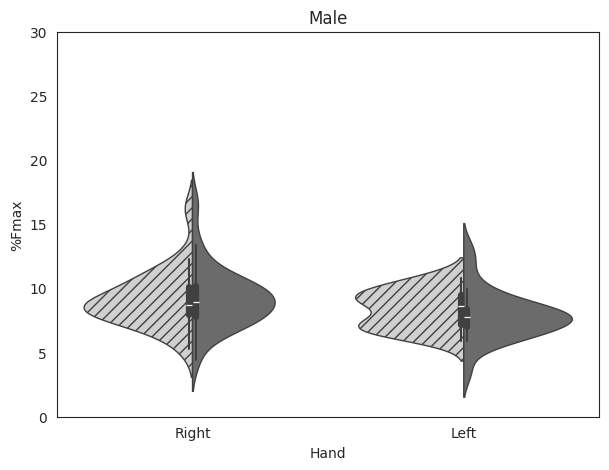

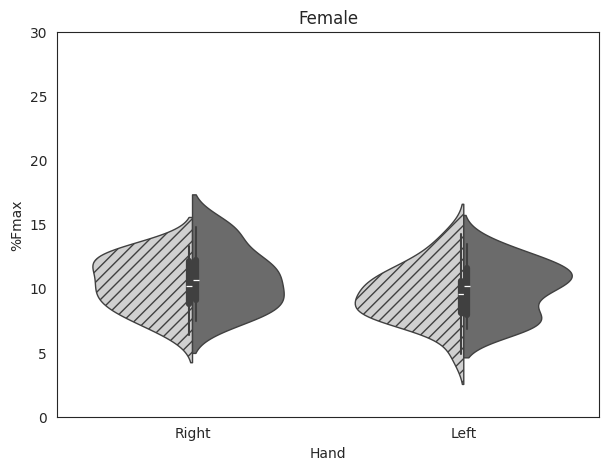

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- PREPARE LONG DATA ----------
df_long = df_clean.melt(
    id_vars=["Gender"],
    value_vars=["%Fmax_FR", "%Fmax_ER", "%Fmax_FL", "%Fmax_EL"],
    var_name="Variable",
    value_name="%Fmax"
)

# Map Hand and Muscle
def map_variable(var):
    if var == "%Fmax_FR":
        return "Right", "Flexor"
    elif var == "%Fmax_ER":
        return "Right", "Extensor"
    elif var == "%Fmax_FL":
        return "Left", "Flexor"
    else:
        return "Left", "Extensor"

df_long[["Hand", "Muscle"]] = df_long["Variable"].apply(
    lambda x: pd.Series(map_variable(x))
)

sns.set_style("white")

# ---------- PLOT ----------
for gender in df_long["Gender"].unique():

    plt.figure(figsize=(7,5))

    subset = df_long[df_long["Gender"] == gender]

    ax = sns.violinplot(
        data=subset,
        x="Hand",
        y="%Fmax",
        hue="Muscle",
        split=True,
        palette=["#D0D0D0", "#6B6B6B"],  # light & dark grey
        linewidth=1,
        inner="box"
    )

    # Add hatching for better B/W distinction
    for i, artist in enumerate(ax.collections):
        if i % 2 == 0:
            artist.set_hatch("///")
        else:
            artist.set_hatch("")

    plt.title(f"{gender}")
    plt.ylabel("%Fmax")
    plt.ylim(0, 30)
    plt.grid(False)
    plt.legend([], [], frameon=False)

    plt.show()

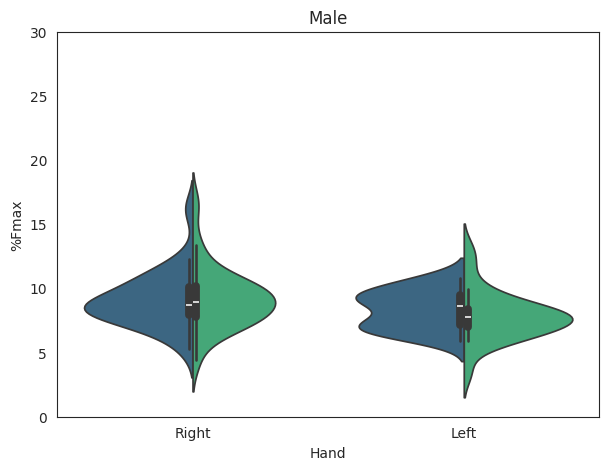

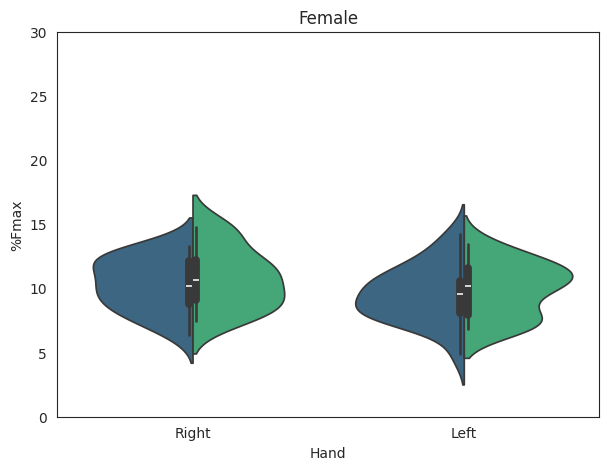

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- PREPARE LONG DATA ----------
df_long = df_clean.melt(
    id_vars=["Gender"],
    value_vars=["%Fmax_FR", "%Fmax_ER", "%Fmax_FL", "%Fmax_EL"],
    var_name="Variable",
    value_name="%Fmax"
)

# Додаємо Hand та Muscle
def map_variable(var):
    if var == "%Fmax_FR":
        return "Right", "Flexor"
    elif var == "%Fmax_ER":
        return "Right", "Extensor"
    elif var == "%Fmax_FL":
        return "Left", "Flexor"
    else:
        return "Left", "Extensor"

df_long[["Hand", "Muscle"]] = df_long["Variable"].apply(
    lambda x: pd.Series(map_variable(x))
)
sns.set_style("white")
# ---------- PLOT SEPARATELY FOR EACH GENDER ----------

for gender in df_long["Gender"].unique():

    plt.figure(figsize=(7,5))

    subset = df_long[df_long["Gender"] == gender]

    sns.violinplot(
        data=subset,
        x="Hand",
        y="%Fmax",
        hue="Muscle",
        split=True,
        palette="viridis"
    )

    plt.title(f"{gender}")
    plt.ylabel("%Fmax")
    plt.ylim(0, 30)
    plt.grid(False)
    plt.legend([], [], frameon=False)
    plt.show()

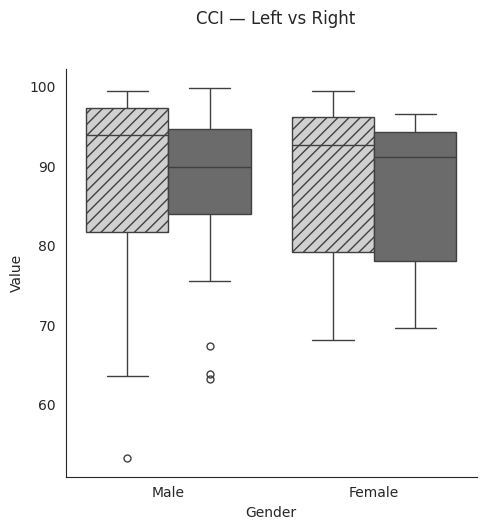

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- LONG FORMAT ----------
df_indices = df_clean.melt(
    id_vars=["Gender"],
    value_vars=["CCI_L", "CCI_R"],
    var_name="Variable",
    value_name="Value"
)

def map_variable(var):
    if var == "CCI_L":
        return "CCI", "Left"
    elif var == "CCI_R":
        return "CCI", "Right"


df_indices[["Index", "Side"]] = df_indices["Variable"].apply(
    lambda x: pd.Series(map_variable(x))
)

sns.set_style("white")

# ---------- PLOT ----------
g = sns.catplot(
    data=df_indices,
    x="Gender",
    y="Value",
    hue="Side",
    col="Index",
    kind="box",
    palette=["#D0D0D0", "#6B6B6B"],  # light, dark
    height=5,
    aspect=1,
    sharey=False,
    linewidth=1
)

# ---------- ADD HATCH ONLY TO LIGHT COLOR ----------
for ax in g.axes.flat:

    # boxplot elements are stored in patches
    for patch in ax.patches:

        # get face color
        facecolor = patch.get_facecolor()

        # convert to grayscale brightness
        brightness = 0.299*facecolor[0] + 0.587*facecolor[1] + 0.114*facecolor[2]

        # if light color → add hatch
        if brightness > 0.6:
            patch.set_hatch("///")
        # dark color остається без штрихування

g._legend.remove()

g.set_titles(template="")
g.set_ylabels("Value")
g.fig.suptitle("CCI — Left vs Right", y=1.05)

plt.show()

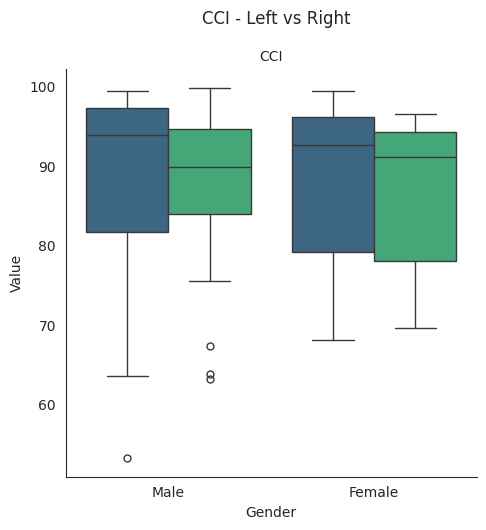

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- LONG FORMAT ----------
df_indices = df_clean.melt(
    id_vars=["Gender"],
    value_vars=["CCI_L", "CCI_R"],
    var_name="Variable",
    value_name="Value"
)

# Додаємо Index та Side
def map_variable(var):
    if var == "CCI_L":
        return "CCI", "Left"
    elif var == "CCI_R":
        return "CCI", "Right"

df_indices[["Index", "Side"]] = df_indices["Variable"].apply(
    lambda x: pd.Series(map_variable(x))
)

# ---------- PLOT ----------
g = sns.catplot(
    data=df_indices,
    x="Gender",
    y="Value",
    hue="Side",
    col="Index",
    kind="box",
    palette="viridis",
    height=5,
    aspect=1,
    sharey=False
)

g._legend.remove()

g.set_titles("{col_name}")
g.set_ylabels("Value")
g.fig.suptitle("CCI - Left vs Right", y=1.05)

plt.show()

# Výpočet a porovnávání CCI můžů a žen, pravá a levá ruce

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

q_columns = [
    'CCI_R', 'CCI_L',
    '%Fmax_FR', '%Fmax_ER',
    '%Fmax_FL', '%Fmax_EL'
]

results = []

for col in q_columns:

    # Розділення по статі
    men = df_clean[df_clean["Gender"] == "Male"][col].dropna()
    women = df_clean[df_clean["Gender"] == "Female"][col].dropna()

    # Mann–Whitney U test
    stat, p = mannwhitneyu(men, women, alternative='two-sided')

    results.append({
        "Variable": col,
        "Median_Men": men.median(),
        "Median_Women": women.median(),
        "p_value": p
    })

results_df = pd.DataFrame(results)

# Округлення
results_df = results_df.round(4)

results_df

,Variable,Median_Men,Median_Women,p_value
0,CCI_R,89.9199,91.1872,0.8604
1,CCI_L,93.9488,92.6314,1.0000
2,%Fmax_FR,8.7200,10.1972,0.0290
3,%Fmax_ER,8.9050,10.6202,0.0199
4,%Fmax_FL,8.6650,9.5950,0.0275
5,%Fmax_EL,7.7450,10.1700,0.0033


In [ ]:
import pandas as pd
from scipy.stats import wilcoxon

# Показники L / R
paired_columns = [
    ('CCI_L', 'CCI_R'),

    ('%Fmax_FL', '%Fmax_FR'),
    ('%Fmax_EL', '%Fmax_ER')
]

results = []

# цикл по статі
for gender in ["Male", "Female"]:

    df_gender = df_clean[df_clean["Gender"] == gender]

    for left_col, right_col in paired_columns:

        subset = df_gender[[left_col, right_col]].dropna()

        if len(subset) > 0:

            stat, p = wilcoxon(subset[left_col], subset[right_col])

            results.append({
                "Gender": gender,
                "Variable_Left": left_col,
                "Variable_Right": right_col,
                "N": len(subset),
                "Median_Left": subset[left_col].median(),
                "Median_Right": subset[right_col].median(),
                "p_value": p
            })

        else:
            results.append({
                "Gender": gender,
                "Variable_Left": left_col,
                "Variable_Right": right_col,
                "Error": "Insufficient paired data"
            })

results_df = pd.DataFrame(results)
results_df.round(4)

,Gender,Variable_Left,Variable_Right,N,Median_Left,Median_Right,p_value
0,Male,CCI_L,CCI_R,26,93.9488,89.9199,0.5338
1,Male,%Fmax_FL,%Fmax_FR,26,8.6650,8.7200,0.0962
2,Male,%Fmax_EL,%Fmax_ER,26,7.7450,8.9050,0.0063
3,Female,CCI_L,CCI_R,22,92.6314,91.1872,0.5028
4,Female,%Fmax_FL,%Fmax_FR,22,9.5950,10.1972,0.0684
5,Female,%Fmax_EL,%Fmax_ER,22,10.1700,10.6202,0.0684


In [ ]:
import pandas as pd
from scipy.stats import wilcoxon

# Показники Flexor / Extensor
paired_columns = [
    ('%Fmax_FL', '%Fmax_EL'),
    ('%Fmax_FR', '%Fmax_ER')
]

results = []

# цикл по статі
for gender in ["Male", "Female"]:

    df_gender = df_clean[df_clean["Gender"] == gender]

    for flex_col, ext_col in paired_columns:

        # беремо тільки рядки без NaN у обох колонках
        subset = df_gender[[flex_col, ext_col]].dropna()

        if len(subset) > 0:

            stat, p = wilcoxon(subset[flex_col], subset[ext_col])

            results.append({
                "Gender": gender,
                "Flexor": flex_col,
                "Extensor": ext_col,
                "N": len(subset),
                "Median_Flexor": subset[flex_col].median(),
                "Median_Extensor": subset[ext_col].median(),
                "p_value": p
            })

        else:
            results.append({
                "Gender": gender,
                "Flexor": flex_col,
                "Extensor": ext_col,
                "Error": "Insufficient paired data"
            })

results_df = pd.DataFrame(results)
results_df.round(4)

,Gender,Flexor,Extensor,N,Median_Flexor,Median_Extensor,p_value
0,Male,%Fmax_FL,%Fmax_EL,26,8.6650,7.7450,0.6567
1,Male,%Fmax_FR,%Fmax_ER,26,8.7200,8.9050,0.5850
2,Female,%Fmax_FL,%Fmax_EL,22,9.5950,10.1700,0.1129
3,Female,%Fmax_FR,%Fmax_ER,22,10.1972,10.6202,0.3369


In [ ]:
women1 = df_clean[df_clean["Gender"] == "Female"].dropna()
women1.head()

,Gender,Laterality,Height,Weight,Age,Occupation,%Fmax_FR,%Fmax_ER,%Fmax_FL,%Fmax_EL,CCI_R,CCI_L
1,Female,right,149,62,53,servírka,9.10,8.20,8.00,7.00,94.797688,93.333333
2,Female,right,167,85,52,pomocná,12.63,11.72,7.25,8.94,96.262834,89.561458
3,Female,right,165,94,52,pomocná,12.16,14.76,13.22,8.08,90.341753,75.868545
5,Female,right,164,75,50,pokojska,13.09,14.48,10.66,11.75,94.958288,95.136100
8,Female,right,165,74,58,PrTrKal,11.47,14.12,10.37,10.86,89.644392,97.691945


In [ ]:
men1 = df_clean[df_clean["Gender"] == "Male"].dropna()
men1.head()

,Gender,Laterality,Height,Weight,Age,Occupation,%Fmax_FR,%Fmax_ER,%Fmax_FL,%Fmax_EL,CCI_R,CCI_L
0,Male,right,185,90,33,kuchař,7.90,10.40,6.50,6.30,86.338798,98.437500
6,Male,right,175,90,28,PrTechL,7.99,10.05,9.35,9.66,88.580931,98.369279
7,Male,right,165,72,44,PrTechL,8.72,10.22,8.86,8.52,92.080253,98.043728
13,Male,right,174,65,38,PrPrani,8.36,10.23,9.45,8.40,89.940828,94.117647
18,Male,right,173,68,45,SklExped,8.03,8.07,7.65,7.56,99.751553,99.408284


In [ ]:
import pandas as pd
from scipy.stats import wilcoxon

# Показники, які мають L / R
paired_columns = [
    ('CCI_L', 'CCI_R'),

    ('%Fmax_FL', '%Fmax_FR'),
    ('%Fmax_EL', '%Fmax_ER')
]

results = []

for left_col, right_col in paired_columns:

    # беремо тільки рядки без NaN у обох колонках
    subset = df_clean[[left_col, right_col]].dropna()

    if len(subset) > 0:

        stat, p = wilcoxon(subset[left_col], subset[right_col])

        results.append({
            "Variable_Left": left_col,
            "Variable_Right": right_col,
            "Median_Left": subset[left_col].median(),
            "Median_Right": subset[right_col].median(),
            "p_value": p
        })
    else:
        results.append({
            "Variable_Left": left_col,
            "Variable_Right": right_col,
            "Error": "Insufficient paired data"
        })

results_df = pd.DataFrame(results)
results_df.round(2)

,Variable_Left,Variable_Right,Median_Left,Median_Right,p_value
0,CCI_L,CCI_R,93.56,90.36,0.35
1,%Fmax_FL,%Fmax_FR,8.84,9.09,0.01
2,%Fmax_EL,%Fmax_ER,8.09,9.57,0.00


In [ ]:
df_clean.columns

Index(['Gender', 'Laterality', 'Height', 'Weight', 'Age', 'Occupation',
       '%Fmax_FR', '%Fmax_ER', '%Fmax_FL', '%Fmax_EL', 'CCI_R', 'CCI_L'],
      dtype='object')

In [ ]:
from statsmodels.multivariate.manova import MANOVA

# беремо тільки потрібні колонки
df_manova = df_clean[
    ["CCI_R","CCI_L","Gender","Age","Height","Weight", 'Laterality', 'Occupation']
].dropna()

# явно задаємо категорії
df_manova["Gender"] = df_manova["Gender"].astype("category")
df_manova["Laterality"] = df_manova["Laterality"].astype("category")

# формула В ОДИН РЯДОК (без переносів!)
formula = "CCI_R + CCI_L ~ Age + Height + Weight + C(Gender)+ C(Occupation)"

manova_all = MANOVA.from_formula(formula, data=df_manova)

print(manova_all.mv_test())

                  Multivariate linear model
                                                              
--------------------------------------------------------------
         Intercept        Value  Num DF  Den DF F Value Pr > F
--------------------------------------------------------------
            Wilks' lambda 0.4566 2.0000 13.0000  7.7348 0.0061
           Pillai's trace 0.5434 2.0000 13.0000  7.7348 0.0061
   Hotelling-Lawley trace 1.1900 2.0000 13.0000  7.7348 0.0061
      Roy's greatest root 1.1900 2.0000 13.0000  7.7348 0.0061
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
         C(Gender)        Value  Num DF  Den DF F Value Pr > F
--------------------------------------------------------------
            Wilks' lambda 0.6534 2.0000 13.0000  3.4482 0.0629
           Pillai's trace 0.3466 2.0000 13.0000  3.4482 0.0629
   Hotellin

In [ ]:
df_clean['Fmax_combined_R'] = df_clean['%Fmax_FR'] + df_clean['%Fmax_ER']
df_clean['Fmax_combined_L'] = df_clean['%Fmax_FL'] + df_clean['%Fmax_EL']

In [ ]:
from statsmodels.multivariate.manova import MANOVA

# беремо тільки потрібні колонки
df_manova_jsi = df_clean[
    ['Fmax_combined_R','Fmax_combined_L',"Gender","Age","Height","Weight", 'Laterality', 'Occupation']
].dropna()

# явно задаємо категорії
df_manova_jsi["Gender"] = df_manova_jsi["Gender"].astype("category")
df_manova_jsi["Laterality"] = df_manova_jsi["Laterality"].astype("category")

# формула В ОДИН РЯДОК (без переносів!)
formula = "Fmax_combined_R + Fmax_combined_L ~ Age + Height + Weight + C(Gender)+ C(Occupation)"

manova_all = MANOVA.from_formula(formula, data=df_manova_jsi)

print(manova_all.mv_test())

                  Multivariate linear model
                                                              
--------------------------------------------------------------
         Intercept        Value  Num DF  Den DF F Value Pr > F
--------------------------------------------------------------
            Wilks' lambda 0.3969 2.0000 13.0000  9.8773 0.0025
           Pillai's trace 0.6031 2.0000 13.0000  9.8773 0.0025
   Hotelling-Lawley trace 1.5196 2.0000 13.0000  9.8773 0.0025
      Roy's greatest root 1.5196 2.0000 13.0000  9.8773 0.0025
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
         C(Gender)        Value  Num DF  Den DF F Value Pr > F
--------------------------------------------------------------
            Wilks' lambda 0.5816 2.0000 13.0000  4.6768 0.0295
           Pillai's trace 0.4184 2.0000 13.0000  4.6768 0.0295
   Hotellin

In [ ]:
df_clean["Occupation"]

,Occupation
0,kuchař
1,servírka
2,pomocná
3,pomocná
5,pokojska
6,PrTechL
7,PrTechL
8,PrTrKal
9,PrTrKal
10,PrObrStr


In [ ]:

# --- списки категорій ---
df_prof = df_clean.copy()
operator_vyroby = [
    'Skladník', "Dělník", 'operátor výroby', 'TechPrac',
    'Svářeč', 'PrSoleni', 'PrMereni', 'PrTrideni',
    'PrPrani', 'PrSolVaz', 'PrObrStr', 'PrTrKal', 'PrTechL'
]

hotel_servis = [
    'pomocna', 'pomocná', 'servírka', 'kuchař', 'Pekar','pokojska', 'pradelník', 'Maser'
]

auto_servis = [
    'Přípravář – autolakýrník', 'MycVoz', 'Lakyrnik',
    'DělnDopr', 'SklExped', 'ElMech', 'Zamecn'
]

# --- спочатку прибираємо пробіли ---
df_prof["Occupation"] = df_prof["Occupation"].str.strip()

# --- заміна по категоріях ---
df_prof["Occupation"] = df_prof["Occupation"].replace(
    operator_vyroby, "production_line"
)

df_prof["Occupation"] = df_prof["Occupation"].replace(
    hotel_servis, "hotel_service"
)

df_prof["Occupation"] = df_prof["Occupation"].replace(
    auto_servis, "auto_service"
)

In [ ]:
df_prof["Occupation"].value_counts()

,count
Occupation,
production_line,19
auto_service,14
hotel_service,13
Ruční mytí a čištění osobních aut,1
myč,1


In [ ]:
from statsmodels.multivariate.manova import MANOVA

# беремо тільки потрібні колонки
df_manova = df_prof[
    ["CCI_R","CCI_L","Gender","Age","Height","Weight", 'Laterality', 'Occupation']
].dropna()

# явно задаємо категорії
df_manova["Gender"] = df_manova["Gender"].astype("category")
df_manova["Laterality"] = df_manova["Laterality"].astype("category")

# формула В ОДИН РЯДОК (без переносів!)
formula = "CCI_R + CCI_L ~ Age + Height + Weight + C(Gender)+ C(Occupation)"

manova_all = MANOVA.from_formula(formula, data=df_manova)

print(manova_all.mv_test())

                 Multivariate linear model
                                                            
------------------------------------------------------------
       Intercept        Value  Num DF  Den DF F Value Pr > F
------------------------------------------------------------
          Wilks' lambda 0.8680 2.0000 38.0000  2.8905 0.0678
         Pillai's trace 0.1320 2.0000 38.0000  2.8905 0.0678
 Hotelling-Lawley trace 0.1521 2.0000 38.0000  2.8905 0.0678
    Roy's greatest root 0.1521 2.0000 38.0000  2.8905 0.0678
------------------------------------------------------------
                                                            
------------------------------------------------------------
       C(Gender)        Value  Num DF  Den DF F Value Pr > F
------------------------------------------------------------
          Wilks' lambda 0.9984 2.0000 38.0000  0.0303 0.9702
         Pillai's trace 0.0016 2.0000 38.0000  0.0303 0.9702
 Hotelling-Lawley trace 0.0016 2.0000 38.0

In [ ]:
from statsmodels.multivariate.manova import MANOVA

# беремо тільки потрібні колонки
df_manova_jsi = df_prof[
    ["Fmax_combined_R","Fmax_combined_L","Gender","Age","Height","Weight", 'Laterality', 'Occupation']
].dropna()

# явно задаємо категорії
df_manova_jsi["Gender"] = df_manova_jsi["Gender"].astype("category")
df_manova_jsi["Laterality"] = df_manova_jsi["Laterality"].astype("category")

# формула В ОДИН РЯДОК (без переносів!)
formula = "Fmax_combined_R + Fmax_combined_L ~ Age + Height + Weight + C(Gender)+ C(Occupation)"

manova_all_jsi = MANOVA.from_formula(formula, data=df_manova_jsi)

print(manova_all_jsi.mv_test())

                 Multivariate linear model
                                                            
------------------------------------------------------------
       Intercept        Value  Num DF  Den DF F Value Pr > F
------------------------------------------------------------
          Wilks' lambda 0.9385 2.0000 38.0000  1.2460 0.2991
         Pillai's trace 0.0615 2.0000 38.0000  1.2460 0.2991
 Hotelling-Lawley trace 0.0656 2.0000 38.0000  1.2460 0.2991
    Roy's greatest root 0.0656 2.0000 38.0000  1.2460 0.2991
------------------------------------------------------------
                                                            
------------------------------------------------------------
       C(Gender)        Value  Num DF  Den DF F Value Pr > F
------------------------------------------------------------
          Wilks' lambda 0.8382 2.0000 38.0000  3.6671 0.0350
         Pillai's trace 0.1618 2.0000 38.0000  3.6671 0.0350
 Hotelling-Lawley trace 0.1930 2.0000 38.0